<a href="https://colab.research.google.com/github/Salman-5004/Bot_Hunter/blob/main/voicedetect.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt


In [4]:
!pip install gradio -q

In [5]:
import gradio as gr

In [25]:
df=pd.read_csv('audio.csv.csv')


In [27]:
df.head()

,Breath_Pauses,Pitch_Perfection,Background_Noise,Label
0,15,88,77,HUMAN
1,10,83,67,HUMAN
2,3,95,47,DEEPFAKE
3,18,75,85,HUMAN
4,12,82,61,HUMAN


In [28]:
x=df[['Breath_Pauses','Pitch_Perfection','Background_Noise']]
y=df['Label']

In [29]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)

In [30]:
x_train.shape,x_test.shape,y_train.shape,y_test.shape

((1120, 3), (280, 3), (1120,), (280,))

In [38]:
y_train.value_counts(normalize=True)

,proportion
Label,
DEEPFAKE,0.5
HUMAN,0.5


In [33]:
cyber_ai=RandomForestClassifier(n_estimators=100,random_state=42)
cyber_ai.fit(x_train,y_train)

RandomForestClassifier(random_state=42)

In [34]:
y_pred=cyber_ai.predict(x_test)

In [39]:
from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

    DEEPFAKE       0.96      0.96      0.96       140
       HUMAN       0.96      0.96      0.96       140

    accuracy                           0.96       280
   macro avg       0.96      0.96      0.96       280
weighted avg       0.96      0.96      0.96       280



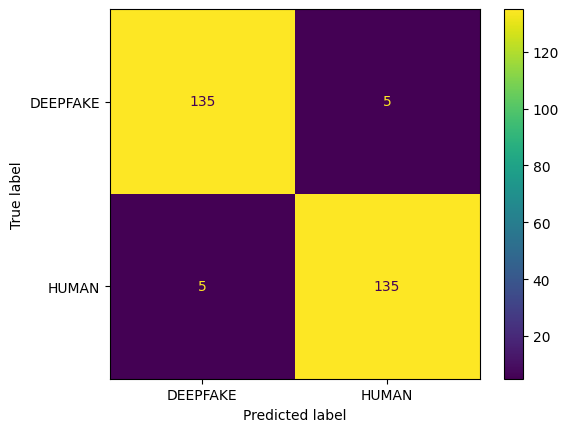

In [42]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_estimator(cyber_ai,x_test,y_test)

In [43]:
# Step 1: Create a function for the AI to make decisions

def detect_deepfake(breath, pitch, noise):
    prediction = cyber_ai.predict([[breath, pitch, noise]])[0]
    confidence = cyber_ai.predict_proba([[breath, pitch, noise]])
    confidence_score = round(max(confidence[0]) * 100, 2)

    if prediction == "DEEPFAKE":
        return f"🚨 SYSTEM ALERT: DEEPFAKE DETECTED! (Confidence: {confidence_score}%)"
    else:
        return f"✅ HUMAN VERIFIED. (Confidence: {confidence_score}%)"


# Step 2: Build the Graphical User Interface (GUI) using Gradio

app = gr.Interface(
    fn=detect_deepfake,
    inputs=[
        gr.Slider(0, 30, label="Breath Pauses (per min)"),
        gr.Slider(50, 100, label="Pitch Perfection Score (%)"),
        gr.Slider(0, 100, label="Background Noise Consistency (%)")
    ],
    outputs=gr.Textbox(label="AI Forensic Result"),
    title="BotHunter: Deepfake Audio Detector",
    description="Adjust the sliders based on the extracted audio features to detect AI voice clones."
)

# Launch the App
app.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://f11de8a7baabc24329.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
